GAIT ANALYSIS: NORMAL vs ATAXIC

📂 STEP 1: Upload NORMAL Gait CSV File
----------------------------------------
Please select the CSV file for NORMAL walking gait:



Saving normal_features_21.csv to normal_features_21.csv

✅ Normal gait file uploaded: normal_features_21.csv

📂 STEP 2: Upload ATAXIC Gait CSV File
----------------------------------------
Please select the CSV file for ATAXIC walking gait:



Saving ataxia_features_1.csv to ataxia_features_1.csv

✅ Ataxic gait file uploaded: ataxia_features_1.csv

STEP 3: LOADING DATA

📊 NORMAL Gait Data:
   Rows: 28540
   Columns: 47

📊 ATAXIC Gait Data:
   Rows: 34651
   Columns: 47

STEP 4: DATA PREVIEW

🔍 NORMAL Gait - First 5 rows:
   XLeftShoulder  YLeftShoulder  ZLeftShoulder  XRightShoulder  \
0       0.149895      -0.456663      -0.145954       -0.176750   
1       0.149325      -0.460170      -0.142796       -0.178158   
2       0.149017      -0.460935      -0.145006       -0.178546   
3       0.148697      -0.464124      -0.143690       -0.179134   
4       0.148681      -0.464125      -0.143385       -0.179064   

   YRightShoulder  ZRightShoulder  XLeftElbow  YLeftElbow  ZLeftElbow  \
0       -0.449895       -0.195041    0.162096   -0.213415   -0.087743   
1       -0.453304       -0.185473    0.162002   -0.216561   -0.087929   
2       -0.453629       -0.185841    0.161871   -0.217690   -0.095596   
3       -0.455492       -0.1

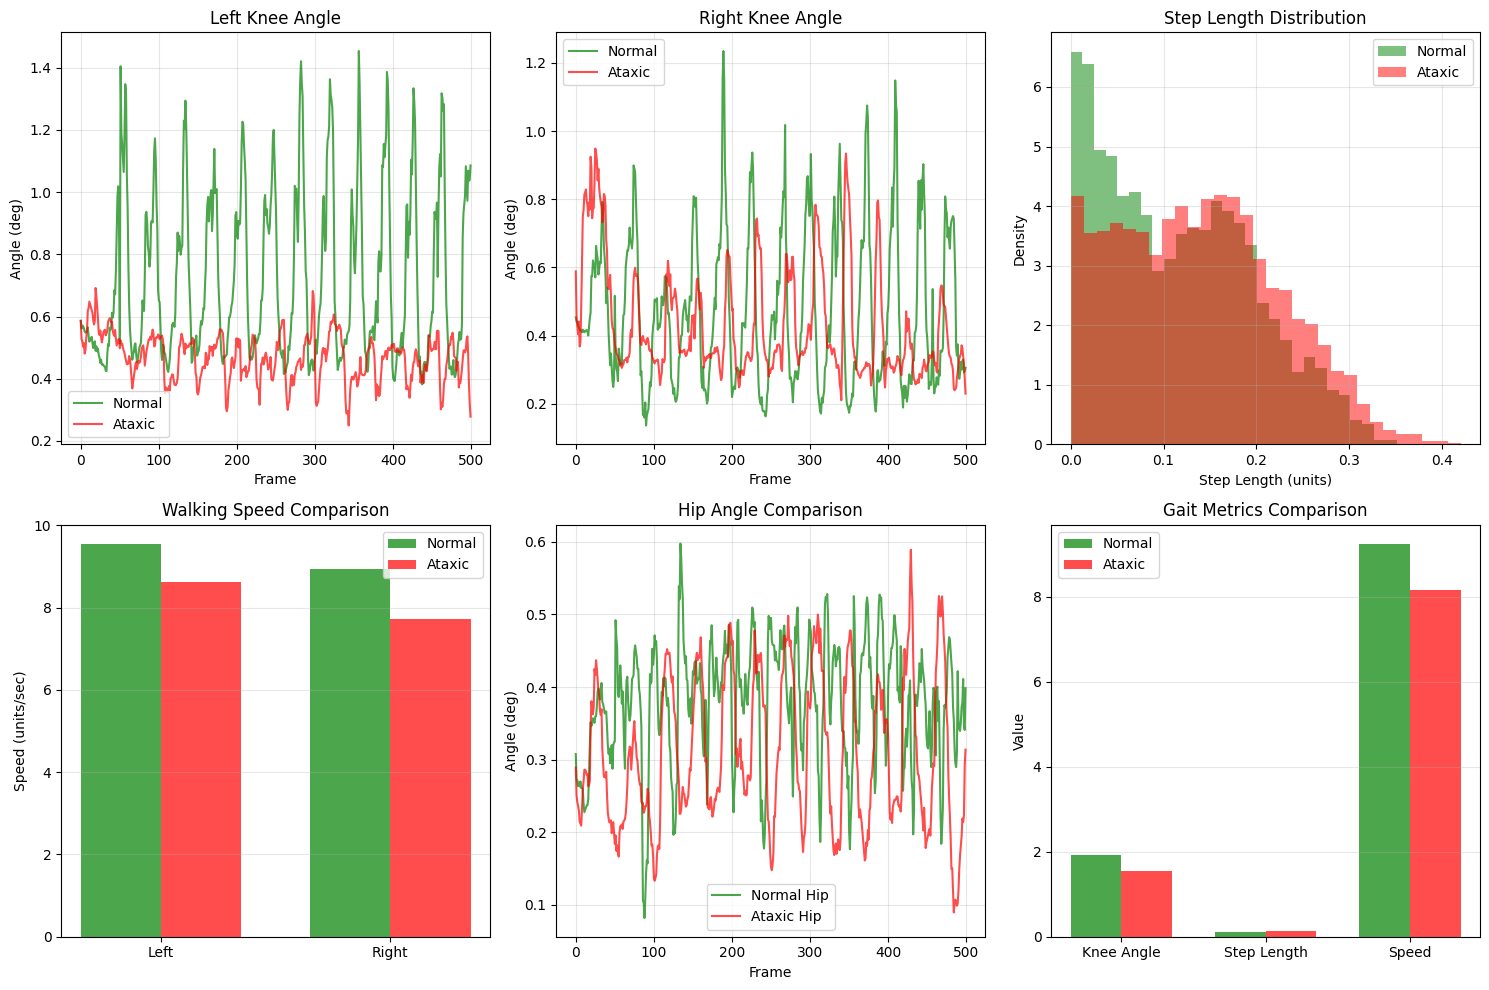


STEP 7: CLINICAL INTERPRETATION

🏃 WALKING SPEED:
   Normal Speed: 9.24 units/sec
   Ataxic Speed: 8.17 units/sec
   Difference: -11.5%

👣 STEP LENGTH:
   Normal Step: 0.115 units
   Ataxic Step: 0.138 units
   Difference: 20.0%

🦵 KNEE ANGLE:
   Normal Knee: 1.9°
   Ataxic Knee: 1.5°
   Difference: -20.4%

FINAL SUMMARY

📁 Files Analyzed:
   Normal: normal_features_21.csv
   Ataxic: ataxia_features_1.csv

📊 Data Size:
   Normal: 28540 rows
   Ataxic: 34651 rows

✅ ANALYSIS COMPLETE!


In [5]:
# ============================================
# GAIT ANALYSIS
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

print("="*60)
print("GAIT ANALYSIS: NORMAL vs ATAXIC")
print("="*60)

# ============================================
# STEP 1: UPLOAD FIRST FILE (NORMAL GAIT)
# ============================================

print("\n STEP 1: Upload NORMAL Gait CSV File")
print("-"*40)
print("Please select the CSV file for NORMAL walking gait:")
print()

uploaded1 = files.upload()

# Get the filename of first file
normal_filename = list(uploaded1.keys())[0]
print(f"\n Normal gait file uploaded: {normal_filename}")

# ============================================
# STEP 2: UPLOAD SECOND FILE (ATAXIC GAIT)
# ============================================

print("\n STEP 2: Upload ATAXIC Gait CSV File")
print("-"*40)
print("Please select the CSV file for ATAXIC walking gait:")
print()

uploaded2 = files.upload()

# Get the filename of second file
ataxic_filename = list(uploaded2.keys())[0]
print(f"\n Ataxic gait file uploaded: {ataxic_filename}")

# ============================================
# STEP 3: LOAD BOTH FILES
# ============================================

print("\n" + "="*60)
print("STEP 3: LOADING DATA")
print("="*60)

# Load normal gait data
normal_df = pd.read_csv(normal_filename)
print(f"\n NORMAL Gait Data:")
print(f"   Rows: {len(normal_df)}")
print(f"   Columns: {len(normal_df.columns)}")

# Load ataxic gait data
ataxic_df = pd.read_csv(ataxic_filename)
print(f"\n ATAXIC Gait Data:")
print(f"   Rows: {len(ataxic_df)}")
print(f"   Columns: {len(ataxic_df.columns)}")

# ============================================
# STEP 4: PREVIEW DATA
# ============================================

print("\n" + "="*60)
print("STEP 4: DATA PREVIEW")
print("="*60)

print("\n NORMAL Gait - First 5 rows:")
print(normal_df.head())

print("\n ATAXIC Gait - First 5 rows:")
print(ataxic_df.head())

# ============================================
# STEP 5: CALCULATE STATISTICS
# ============================================

print("\n" + "="*60)
print("STEP 5: GAIT STATISTICS COMPARISON")
print("="*60)

# Function to calculate gait metrics
def calculate_metrics(df, name):
    metrics = {}

    # Knee angles
    if 'ThetaLeftKnee' in df.columns:
        metrics['left_knee'] = df['ThetaLeftKnee'].mean()
        metrics['right_knee'] = df['ThetaRightKnee'].mean()
        metrics['knee_avg'] = (metrics['left_knee'] + metrics['right_knee']) / 2

    # Hip angles
    if 'ThetaLeftHip' in df.columns:
        metrics['left_hip'] = df['ThetaLeftHip'].mean()
        metrics['right_hip'] = df['ThetaRightHip'].mean()

    # Step length
    if 'StepLength' in df.columns:
        metrics['step_length'] = df['StepLength'].mean()

    # Walking speed
    if 'LeftStrideSpeed' in df.columns:
        metrics['left_speed'] = df['LeftStrideSpeed'].mean()
        metrics['right_speed'] = df['RightStrideSpeed'].mean()
        metrics['avg_speed'] = (metrics['left_speed'] + metrics['right_speed']) / 2

    # Feet clearance
    if 'FeetClearance' in df.columns:
        metrics['clearance'] = df['FeetClearance'].mean()

    return metrics

# Calculate metrics for both
normal_metrics = calculate_metrics(normal_df, "Normal")
ataxic_metrics = calculate_metrics(ataxic_df, "Ataxic")

# Display comparison table
print("\n COMPARISON TABLE:")
print("-"*60)
print(f"{'Metric':<25} {'NORMAL':<15} {'ATAXIC':<15}")
print("-"*60)

if 'knee_avg' in normal_metrics:
    print(f"{'Knee Angle (avg)':<25} {normal_metrics['knee_avg']:<15.1f} {ataxic_metrics['knee_avg']:<15.1f}")

if 'left_knee' in normal_metrics:
    print(f"{'Left Knee':<25} {normal_metrics['left_knee']:<15.1f} {ataxic_metrics['left_knee']:<15.1f}")
    print(f"{'Right Knee':<25} {normal_metrics['right_knee']:<15.1f} {ataxic_metrics['right_knee']:<15.1f}")

if 'left_hip' in normal_metrics:
    print(f"{'Left Hip':<25} {normal_metrics['left_hip']:<15.1f} {ataxic_metrics['left_hip']:<15.1f}")
    print(f"{'Right Hip':<25} {normal_metrics['right_hip']:<15.1f} {ataxic_metrics['right_hip']:<15.1f}")

if 'step_length' in normal_metrics:
    print(f"{'Step Length':<25} {normal_metrics['step_length']:<15.3f} {ataxic_metrics['step_length']:<15.3f}")

if 'avg_speed' in normal_metrics:
    print(f"{'Walking Speed':<25} {normal_metrics['avg_speed']:<15.2f} {ataxic_metrics['avg_speed']:<15.2f}")

if 'clearance' in normal_metrics:
    print(f"{'Feet Clearance':<25} {normal_metrics['clearance']:<15.3f} {ataxic_metrics['clearance']:<15.3f}")

# ============================================
# STEP 6: VISUALIZATIONS
# ============================================

print("\n" + "="*60)
print("STEP 6: GENERATING PLOTS")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot 1: Left Knee Angle Comparison
if 'ThetaLeftKnee' in normal_df.columns:
    axes[0,0].plot(normal_df['ThetaLeftKnee'][:500], label='Normal', color='green', alpha=0.7)
    axes[0,0].plot(ataxic_df['ThetaLeftKnee'][:500], label='Ataxic', color='red', alpha=0.7)
    axes[0,0].set_xlabel('Frame')
    axes[0,0].set_ylabel('Angle (deg)')
    axes[0,0].set_title('Left Knee Angle')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)

# Plot 2: Right Knee Angle Comparison
if 'ThetaRightKnee' in normal_df.columns:
    axes[0,1].plot(normal_df['ThetaRightKnee'][:500], label='Normal', color='green', alpha=0.7)
    axes[0,1].plot(ataxic_df['ThetaRightKnee'][:500], label='Ataxic', color='red', alpha=0.7)
    axes[0,1].set_xlabel('Frame')
    axes[0,1].set_ylabel('Angle (deg)')
    axes[0,1].set_title('Right Knee Angle')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)

# Plot 3: Step Length Distribution
if 'StepLength' in normal_df.columns:
    axes[0,2].hist(normal_df['StepLength'].dropna(), bins=30, alpha=0.5, label='Normal', color='green', density=True)
    axes[0,2].hist(ataxic_df['StepLength'].dropna(), bins=30, alpha=0.5, label='Ataxic', color='red', density=True)
    axes[0,2].set_xlabel('Step Length (units)')
    axes[0,2].set_ylabel('Density')
    axes[0,2].set_title('Step Length Distribution')
    axes[0,2].legend()
    axes[0,2].grid(True, alpha=0.3)

# Plot 4: Walking Speed Comparison
if 'LeftStrideSpeed' in normal_df.columns:
    speeds_normal = [normal_df['LeftStrideSpeed'].mean(), normal_df['RightStrideSpeed'].mean()]
    speeds_ataxic = [ataxic_df['LeftStrideSpeed'].mean(), ataxic_df['RightStrideSpeed'].mean()]

    x = np.arange(2)
    width = 0.35

    axes[1,0].bar(x - width/2, speeds_normal, width, label='Normal', color='green', alpha=0.7)
    axes[1,0].bar(x + width/2, speeds_ataxic, width, label='Ataxic', color='red', alpha=0.7)
    axes[1,0].set_xticks(x)
    axes[1,0].set_xticklabels(['Left', 'Right'])
    axes[1,0].set_ylabel('Speed (units/sec)')
    axes[1,0].set_title('Walking Speed Comparison')
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3, axis='y')

# Plot 5: Hip Angle Comparison
if 'ThetaLeftHip' in normal_df.columns:
    axes[1,1].plot(normal_df['ThetaLeftHip'][:500], label='Normal Hip', color='green', alpha=0.7)
    axes[1,1].plot(ataxic_df['ThetaLeftHip'][:500], label='Ataxic Hip', color='red', alpha=0.7)
    axes[1,1].set_xlabel('Frame')
    axes[1,1].set_ylabel('Angle (deg)')
    axes[1,1].set_title('Hip Angle Comparison')
    axes[1,1].legend()
    axes[1,1].grid(True, alpha=0.3)

# Plot 6: Summary Bar Chart
metrics_to_plot = []
normal_values = []
ataxic_values = []

if 'knee_avg' in normal_metrics:
    metrics_to_plot.append('Knee Angle')
    normal_values.append(normal_metrics['knee_avg'])
    ataxic_values.append(ataxic_metrics['knee_avg'])

if 'step_length' in normal_metrics:
    metrics_to_plot.append('Step Length')
    normal_values.append(normal_metrics['step_length'])
    ataxic_values.append(ataxic_metrics['step_length'])

if 'avg_speed' in normal_metrics:
    metrics_to_plot.append('Speed')
    normal_values.append(normal_metrics['avg_speed'])
    ataxic_values.append(ataxic_metrics['avg_speed'])

if metrics_to_plot:
    x = np.arange(len(metrics_to_plot))
    width = 0.35

    axes[1,2].bar(x - width/2, normal_values, width, label='Normal', color='green', alpha=0.7)
    axes[1,2].bar(x + width/2, ataxic_values, width, label='Ataxic', color='red', alpha=0.7)
    axes[1,2].set_xticks(x)
    axes[1,2].set_xticklabels(metrics_to_plot)
    axes[1,2].set_ylabel('Value')
    axes[1,2].set_title('Gait Metrics Comparison')
    axes[1,2].legend()
    axes[1,2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ============================================
# STEP 7: CLINICAL INTERPRETATION
# ============================================

print("\n" + "="*60)
print("STEP 7: CLINICAL INTERPRETATION")
print("="*60)

if 'avg_speed' in normal_metrics and 'avg_speed' in ataxic_metrics:
    speed_diff = ((ataxic_metrics['avg_speed'] - normal_metrics['avg_speed']) / normal_metrics['avg_speed']) * 100

    print(f"\n WALKING SPEED:")
    print(f"   Normal Speed: {normal_metrics['avg_speed']:.2f} units/sec")
    print(f"   Ataxic Speed: {ataxic_metrics['avg_speed']:.2f} units/sec")
    print(f"   Difference: {speed_diff:.1f}%")

    if speed_diff < -20:
        print("    Ataxic gait shows SIGNIFICANTLY SLOWER walking speed")
        print("   → This indicates mobility impairment and increased fall risk")

if 'step_length' in normal_metrics and 'step_length' in ataxic_metrics:
    step_diff = ((ataxic_metrics['step_length'] - normal_metrics['step_length']) / normal_metrics['step_length']) * 100

    print(f"\n STEP LENGTH:")
    print(f"   Normal Step: {normal_metrics['step_length']:.3f} units")
    print(f"   Ataxic Step: {ataxic_metrics['step_length']:.3f} units")
    print(f"   Difference: {step_diff:.1f}%")

    if step_diff < -15:
        print("    Ataxic gait shows REDUCED step length")
        print("   → Shorter steps are common in neurological gait disorders")

if 'knee_avg' in normal_metrics and 'knee_avg' in ataxic_metrics:
    knee_diff = ((ataxic_metrics['knee_avg'] - normal_metrics['knee_avg']) / normal_metrics['knee_avg']) * 100

    print(f"\n KNEE ANGLE:")
    print(f"   Normal Knee: {normal_metrics['knee_avg']:.1f}°")
    print(f"   Ataxic Knee: {ataxic_metrics['knee_avg']:.1f}°")
    print(f"   Difference: {knee_diff:.1f}%")

# ============================================
# STEP 8: FINAL SUMMARY
# ============================================

print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)

print(f"\n Files Analyzed:")
print(f"   Normal: {normal_filename}")
print(f"   Ataxic: {ataxic_filename}")

print(f"\n Data Size:")
print(f"   Normal: {len(normal_df)} rows")
print(f"   Ataxic: {len(ataxic_df)} rows")

print("\n ANALYSIS COMPLETE!")
print("="*60)